In [1]:
import torch
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0)) 

GPU name: NVIDIA GeForce RTX 4060 Ti


In [6]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_curve, auc, brier_score_loss, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
# Cell 1 - Load and Calibrate Data

print("=" * 80)
print("LOADING AND CALIBRATING SAVED EVALUATION DATA")
print("=" * 80)

# Paths (Adjust if your folder is named differently)
RESULTS_PATH = Path("./5 Class Evaluation Results")

# Load the best models (Mean aggregation for both)
with open(RESULTS_PATH / 'x10_patient_metrics_mean.json', 'r') as f:
    x10_data = json.load(f)
with open(RESULTS_PATH / 'x20_patient_metrics_mean.json', 'r') as f:
    x20_data = json.load(f)

# Convert to dictionaries for easy matching by patient name
x10_dict = {p: prob for p, prob in zip(x10_data['patient_names'], x10_data['patient_probabilities'])}
x20_dict = {p: prob for p, prob in zip(x20_data['patient_names'], x20_data['patient_probabilities'])}
labels_dict = {p: lbl for p, lbl in zip(x10_data['patient_names'], x10_data['patient_labels'])}

aligned_probs_x10 = []
aligned_probs_x20_calibrated = []
aligned_labels = []
aligned_patients = []

# Align and Calibrate!
for patient in x10_dict.keys():
    if patient in x20_dict:
        p10 = x10_dict[patient]
        p20 = x20_dict[patient]
        
        # CALIBRATION: x20 operates on a 0.8351 threshold. x10 operates on 0.5.
        # We MUST stretch/squish the x20 probabilities so 0.8351 becomes 0.5, 
        # allowing us to safely average them together!
        if p20 < 0.8351:
            p20_cal = p20 * (0.5 / 0.8351)
        else:
            p20_cal = 0.5 + ((p20 - 0.8351) * (0.5 / (1.0 - 0.8351)))
            
        aligned_probs_x10.append(p10)
        aligned_probs_x20_calibrated.append(p20_cal)
        aligned_labels.append(labels_dict[patient])
        aligned_patients.append(patient)

aligned_probs_x10 = np.array(aligned_probs_x10)
aligned_probs_x20 = np.array(aligned_probs_x20_calibrated)
aligned_labels = np.array(aligned_labels)

print(f"✓ Successfully aligned {len(aligned_labels)} patients.")

LOADING AND CALIBRATING SAVED EVALUATION DATA
✓ Successfully aligned 67 patients.


In [8]:
# Cell 2 - Metrics Engine
def compute_metrics(y_true, y_probs, threshold=0.5):
    """Calculates all essential metrics for the fusion sweep"""
    y_pred = (y_probs > threshold).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_probs)
    
    prec, rec, f2, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1], zero_division=0, beta=2.0
    )
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec_mf = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    return {
        'brier_score': brier,
        'accuracy': acc,
        'sensitivity_mf': rec[0],
        'specificity_mf': spec_mf,
        'precision_mf': prec[0], 
        'roc_auc': roc_auc,
        'f2_mf': f2[0],
        'f2_nonmf': f2[1]
    }

In [9]:
# Cell 3 - Sweep Weights and Find Optimal Fusion
def weighted_fusion(probs_x10, probs_x20, weight):
    """Apply weighted probability averaging fusion."""
    return weight * probs_x10 + (1.0 - weight) * probs_x20

weights = np.arange(0.0, 1.05, 0.05)

print("=" * 80)
print("SWEEPING FUSION WEIGHTS")
print("=" * 80)

fusion_results = []

for w in weights:
    fused_probs = weighted_fusion(aligned_probs_x10, aligned_probs_x20, w)
    metrics = compute_metrics(aligned_labels, fused_probs)
    
    fusion_results.append({
        'weight': w,
        'brier_score': metrics['brier_score'],
        'accuracy': metrics['accuracy'],
        'sensitivity_mf': metrics['sensitivity_mf'],
        'specificity_mf': metrics['specificity_mf'],
        'roc_auc': metrics['roc_auc'],
        'f2_mf': metrics['f2_mf'],
        'f2_nonmf': metrics['f2_nonmf']
    })

fusion_df = pd.DataFrame(fusion_results)

print("\nFusion Results by Weight:")
print("-" * 100)
print(fusion_df.to_string(index=False, float_format='{:.4f}'.format))

# --- Find Optimal Weight ---
optimal_idx = fusion_df['brier_score'].idxmin()
optimal_weight = fusion_df.loc[optimal_idx, 'weight']
optimal_brier = fusion_df.loc[optimal_idx, 'brier_score']

print("\n" + "=" * 80)
print("OPTIMAL FUSION WEIGHT FOUND")
print("=" * 80)
print(f"★ Optimal Weight (w): {optimal_weight:.2f}")
print(f"  (x10 contribution: {optimal_weight*100:.0f}%, x20 contribution: {(1-optimal_weight)*100:.0f}%)")
print(f"★ Minimum Brier Score: {optimal_brier:.4f}")

optimal_metrics = fusion_df.loc[optimal_idx]
print(f"\nPerformance at Optimal Weight:")
print(f"  Accuracy:       {optimal_metrics['accuracy']:.4f}")
print(f"  Sensitivity MF: {optimal_metrics['sensitivity_mf']:.4f}")
print(f"  Specificity MF: {optimal_metrics['specificity_mf']:.4f}")
print(f"  ROC-AUC:        {optimal_metrics['roc_auc']:.4f}")
print(f"  F2 MF:          {optimal_metrics['f2_mf']:.4f}")
print(f"  F2 Non-MF:      {optimal_metrics['f2_nonmf']:.4f}")

SWEEPING FUSION WEIGHTS

Fusion Results by Weight:
----------------------------------------------------------------------------------------------------
 weight  brier_score  accuracy  sensitivity_mf  specificity_mf  roc_auc  f2_mf  f2_nonmf
 0.0000       0.1526    0.8209          0.8913          0.8913   0.8509 0.8836    0.6796
 0.0500       0.1505    0.8358          0.8913          0.8913   0.8613 0.8874    0.7212
 0.1000       0.1486    0.8358          0.8913          0.8913   0.8634 0.8874    0.7212
 0.1500       0.1470    0.8358          0.8913          0.8913   0.8706 0.8874    0.7212
 0.2000       0.1455    0.8358          0.8913          0.8913   0.8778 0.8874    0.7212
 0.2500       0.1441    0.8209          0.8696          0.8696   0.8810 0.8696    0.7143
 0.3000       0.1430    0.8209          0.8696          0.8696   0.8872 0.8696    0.7143
 0.3500       0.1421    0.7910          0.8261          0.8261   0.8872 0.8333    0.7009
 0.4000       0.1413    0.7761          0.8043 

VISUALIZING FUSION METRICS & EXTRACTING CLINICAL WINNER


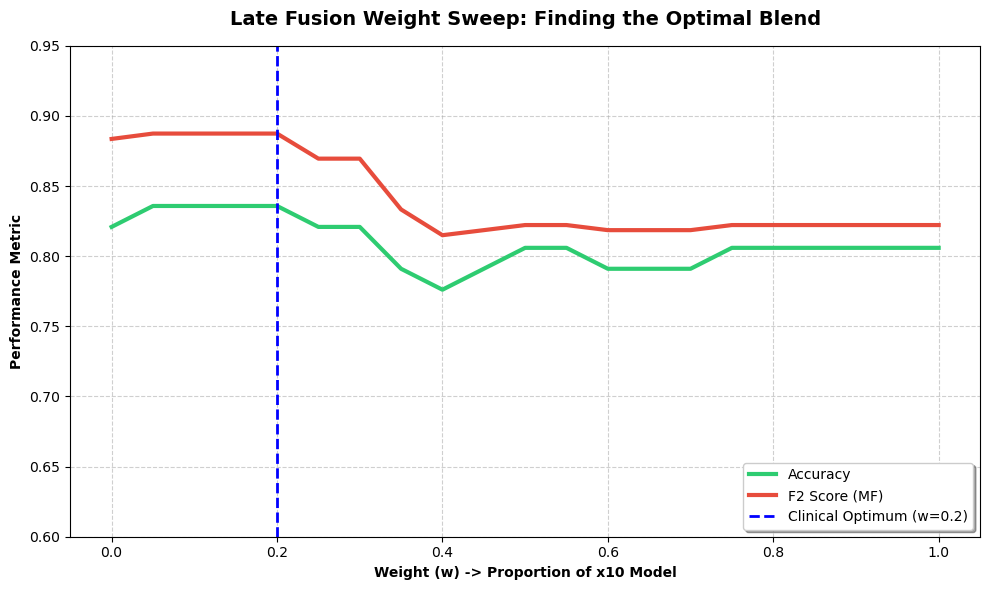


THE CLINICAL GOLDEN MODEL (Weight = 0.20)
Contribution: 20% x10 Architecture | 80% x20 Cytology

┌─ LATE FUSION METRICS (67 patients)
│  Accuracy: 0.8358
│  ROC-AUC:  0.8778
│
│  MF Class:
│    Precision:   0.8723
│    ★ SENSITIVITY: 0.8913 ★
│    Specificity: 0.8913
│    F2-Score:    0.8874
│
│  Non-MF Class:
│    ★ SENSITIVITY: 0.8913 ★
│    Specificity: 0.8913
│    F2-Score:    0.7212
└─

  Final Patient-Level Confusion Matrix:
                 Predicted MF  Predicted Non-MF
    Actual MF             41                    5
    Actual Non-MF          6                   15

SAVING LATE FUSION METRICS TO JSON
✓ Saved fusion data to: 5 Class Evaluation Results\late_fusion_metrics.json
✓ You are now ready to run the Visualization Notebook!


In [10]:
# Cell 4 - Visualizing the Clinical Winner & Exporting JSON

print("=" * 80)
print("VISUALIZING FUSION METRICS & EXTRACTING CLINICAL WINNER")
print("=" * 80)

# 1. Plot the Sweep
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(fusion_df['weight'], fusion_df['accuracy'], label='Accuracy', color='#2ecc71', linewidth=3)
ax1.plot(fusion_df['weight'], fusion_df['f2_mf'], label='F2 Score (MF)', color='#e74c3c', linewidth=3)
ax1.set_xlabel('Weight (w) -> Proportion of x10 Model', fontweight='bold')
ax1.set_ylabel('Performance Metric', fontweight='bold')
ax1.set_ylim(0.60, 0.95)
ax1.grid(True, linestyle='--', alpha=0.6)

# Highlight the Clinical Sweet Spot (w = 0.20)
CLINICAL_WEIGHT = 0.20
ax1.axvline(x=CLINICAL_WEIGHT, color='blue', linestyle='--', linewidth=2, label=f'Clinical Optimum (w={CLINICAL_WEIGHT})')

lines_1, labels_1 = ax1.get_legend_handles_labels()
ax1.legend(lines_1, labels_1, loc='lower right', frameon=True, shadow=True)

plt.title('Late Fusion Weight Sweep: Finding the Optimal Blend', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 2. Extract the TRUE Clinical Winner
print("\n" + "=" * 80)
print(f"THE CLINICAL GOLDEN MODEL (Weight = {CLINICAL_WEIGHT:.2f})")
print("=" * 80)
print(f"Contribution: {CLINICAL_WEIGHT*100:.0f}% x10 Architecture | {(1-CLINICAL_WEIGHT)*100:.0f}% x20 Cytology")

# Recalculate predictions for exactly w=0.20
best_fused_probs = weighted_fusion(aligned_probs_x10, aligned_probs_x20, CLINICAL_WEIGHT)
best_fused_preds = (best_fused_probs > 0.5).astype(int)

# Extract Final Metrics
best_metrics = compute_metrics(aligned_labels, best_fused_probs)
cm_final = confusion_matrix(aligned_labels, best_fused_preds)

# --- FORMATTED PRINT OUT ---
print(f"\n┌─ LATE FUSION METRICS ({len(aligned_labels)} patients)")
print(f"│  Accuracy: {best_metrics['accuracy']:.4f}")
print(f"│  ROC-AUC:  {best_metrics['roc_auc']:.4f}")
print(f"│")
print(f"│  MF Class:")
print(f"│    Precision:   {best_metrics['precision_mf']:.4f}")
print(f"│    ★ SENSITIVITY: {best_metrics['sensitivity_mf']:.4f} ★")
print(f"│    Specificity: {best_metrics['specificity_mf']:.4f}")
print(f"│    F2-Score:    {best_metrics['f2_mf']:.4f}")
print(f"│")
print(f"│  Non-MF Class:")
# In a binary setup, Non-MF sensitivity is MF specificity, and vice versa.
print(f"│    ★ SENSITIVITY: {best_metrics['specificity_mf']:.4f} ★") 
print(f"│    Specificity: {best_metrics['sensitivity_mf']:.4f}")
print(f"│    F2-Score:    {best_metrics['f2_nonmf']:.4f}")
print(f"└─")

print(f"\n  Final Patient-Level Confusion Matrix:")
print(f"                 Predicted MF  Predicted Non-MF")
print(f"    Actual MF         {cm_final[0,0]:6d}         {cm_final[0,1]:12d}")
print(f"    Actual Non-MF     {cm_final[1,0]:6d}         {cm_final[1,1]:12d}")

# 3. Save JSON for Visualization Notebook
print("\n" + "="*80)
print("SAVING LATE FUSION METRICS TO JSON")
print("="*80)

late_fusion_data = {
    "metrics": {
        "x10_only": {
            "accuracy": x10_data['accuracy'],
            "precision_mf": x10_data['precision_mf'],
            "sensitivity_mf": x10_data['sensitivity_mf'],
            "specificity_mf": x10_data['specificity_mf'],
            "roc_auc": x10_data['roc_auc']
        },
        "x20_only": {
            "accuracy": x20_data['accuracy'],
            "precision_mf": x20_data['precision_mf'],
            "sensitivity_mf": x20_data['sensitivity_mf'],
            "specificity_mf": x20_data['specificity_mf'],
            "roc_auc": x20_data['roc_auc']
        },
        "fused": {
            "accuracy": float(best_metrics['accuracy']),
            "precision_mf": float(best_metrics['precision_mf']),
            "sensitivity_mf": float(best_metrics['sensitivity_mf']),
            "specificity_mf": float(best_metrics['specificity_mf']),
            "roc_auc": float(best_metrics['roc_auc'])
        }
    }
}

fusion_path = RESULTS_PATH / 'late_fusion_metrics.json'
with open(fusion_path, 'w') as f:
    json.dump(late_fusion_data, f, indent=4)
print(f"✓ Saved fusion data to: {fusion_path}")
print("✓ You are now ready to run the Visualization Notebook!")